In [1]:
import os
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image

v = 6
MASK_PATH = Path(f"plan_{v}_mask/plan_{v}_mask.png")

MASK_FORMAT = "color"

# Area thresholds can be absolute pixel values or fractions of image area.
# Fractions make the notebook behave better across differently sized plans.
ROOM_MIN_AREA = 0.001
CONNECTOR_MIN_AREA = 0.00002
WALL_MIN_AREA = 0.00005
MATCH_TOLERANCE = 6
CONTOUR_MODE = "poly"  # "poly" or "bbox"
SEAL_KSIZE = "auto"    # "auto" or one integer, e.g. 7

FUSE_KERNEL_SIZE = 5
BRIDGE_TO_WALLS = True
BRIDGE_MAX_GAP = 20
BRIDGE_TOUCH_RADIUS = 2
BRIDGE_MIN_PIXELS = 6

KEEP_OUTSIDE_EDGES = True
SAMPLE_ID = MASK_PATH.stem
OUTDIR = MASK_PATH.with_suffix("")
OUTDIR.mkdir(parents=True, exist_ok=True)
OUT_BASE = OUTDIR / MASK_PATH.stem

print(f"Mask path: {MASK_PATH.resolve()}")
print(f"Output base: {OUT_BASE.resolve()}")

BACKGROUND_ID = 0
WALL_ID = 1
DOOR_ID = 2
WINDOW_ID = 3
OUTSIDE_ID = -1

LABELS = {0: "background", 1: "wall", 2: "door", 3: "window"}
CONNECTOR_IDS = {DOOR_ID, WINDOW_ID}
BARRIER_IDS = [WALL_ID, DOOR_ID, WINDOW_ID]

COLOR_MAP = {
    0: (200, 200, 200),
    1: (40, 40, 40),
    2: (160, 82, 45),
    3: (135, 206, 250),
}

CLASS_COLORS = np.array([COLOR_MAP[i] for i in range(4)], dtype=np.float32) / 255.0
CLASS_CMAP = ListedColormap(CLASS_COLORS)
CLASS_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], CLASS_CMAP.N)


Mask path: /Users/butchiadari/Desktop/Synthetic_Data_Gen/plan_6_mask/plan_6_mask.png
Output base: /Users/butchiadari/Desktop/Synthetic_Data_Gen/plan_6_mask/plan_6_mask/plan_6_mask


In [2]:
def print_class_histogram(mask, tag="classes"):
    ids, counts = np.unique(mask, return_counts=True)
    total = mask.size
    rows = []
    for cls_id, count in zip(ids, counts):
        rows.append({
            "id": int(cls_id),
            "class": LABELS.get(int(cls_id), str(cls_id)),
            "pixels": int(count),
            "percent": round(100 * int(count) / total, 3),
        })
    df = pd.DataFrame(rows)
    print(f"[{tag}] shape={mask.shape}, total_pixels={total}")
    display(df)
    return df


def resolve_area_threshold(value, shape, minimum=1):
    """Use floats < 1 as image-area fractions; otherwise use raw pixels."""
    if isinstance(value, float) and value < 1:
        return max(minimum, int(round(value * shape[0] * shape[1])))
    return max(minimum, int(round(value)))


def mask_to_rgb(mask, color_map=COLOR_MAP):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), np.uint8)
    for cls, color in color_map.items():
        rgb[mask == cls] = color
    return rgb


def show_label_mask(mask, title="mask", figsize=(8, 8), alpha=1.0):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mask, cmap=CLASS_CMAP, norm=CLASS_NORM, interpolation="nearest", alpha=alpha)
    handles = [Line2D([0], [0], marker="s", linestyle="", color=CLASS_COLORS[i], label=f"{i}: {LABELS[i]}") for i in range(4)]
    ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig


def show_binary(mask, title="binary mask", figsize=(8, 8)):  
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mask, cmap="gray", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig


def show_components(label_map, title="components", background=-1, figsize=(8, 8)):
    data = label_map.astype(float).copy()
    data[label_map == background] = np.nan
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, cmap="tab20", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()
    return fig


def overlay_room_contours(mask, rooms, title="rooms", figsize=(9, 9)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mask_to_rgb(mask), interpolation="nearest")
    cmap = plt.colormaps["tab20"]
    for room in rooms:
        contour = room.get("contour")
        cx, cy = room["centroid_px"]
        color = cmap(room["id"] % 20)
        if contour and len(contour) >= 3:
            ax.add_patch(MplPolygon(contour, closed=True, facecolor=color, edgecolor="black", alpha=0.35, linewidth=1.2))
        ax.scatter([cx], [cy], s=180, color=color, edgecolors="black", linewidths=1.1, zorder=5)
        ax.text(cx, cy, str(room["id"]), ha="center", va="center", fontsize=8, fontweight="bold", zorder=6)
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig


def overlay_connectors(mask, connectors, title="connectors", figsize=(9, 9)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mask_to_rgb(mask), interpolation="nearest")
    colors = {DOOR_ID: "#ff7f0e", WINDOW_ID: "#1f78ff"}
    for conn in connectors:
        cx, cy = conn["centroid_px"]
        color = colors.get(conn["label_id"], "white")
        contour = conn.get("contour")
        if contour and len(contour) >= 3:
            ax.add_patch(MplPolygon(contour, closed=True, facecolor="none", edgecolor=color, linewidth=2.0))
        ax.scatter([cx], [cy], s=70, marker="D", color=color, edgecolors="white", linewidths=1, zorder=5)
        ax.text(cx + 3, cy + 3, f"{conn['id']}:{conn['type']}", color=color, fontsize=8, weight="bold")
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig


In [3]:
def load_label_mask(path):
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(path)
    if img.ndim == 3:
        img = img[..., 0]
    return img.astype(np.int32)


def load_color_mask_exact(path, color_map=COLOR_MAP, tolerance=10):
    rgb = np.array(Image.open(path).convert("RGB"))
    rgb_i = rgb.astype(np.int16)
    colors = np.array([color_map[i] for i in sorted(color_map)], dtype=np.int16)

    # Snap every pixel to the nearest known class color. Pixels farther than
    # tolerance are reported so bad generations are visible during debugging.
    dist = np.abs(rgb_i[..., None, :] - colors[None, None, :, :]).sum(axis=-1)
    nearest = dist.argmin(axis=-1).astype(np.int32)
    min_dist = dist.min(axis=-1)
    unmatched = min_dist > tolerance

    label = nearest.copy()
    label[unmatched] = BACKGROUND_ID
    return label, unmatched, rgb


Pixels farther than decode tolerance from COLOR_MAP: 0


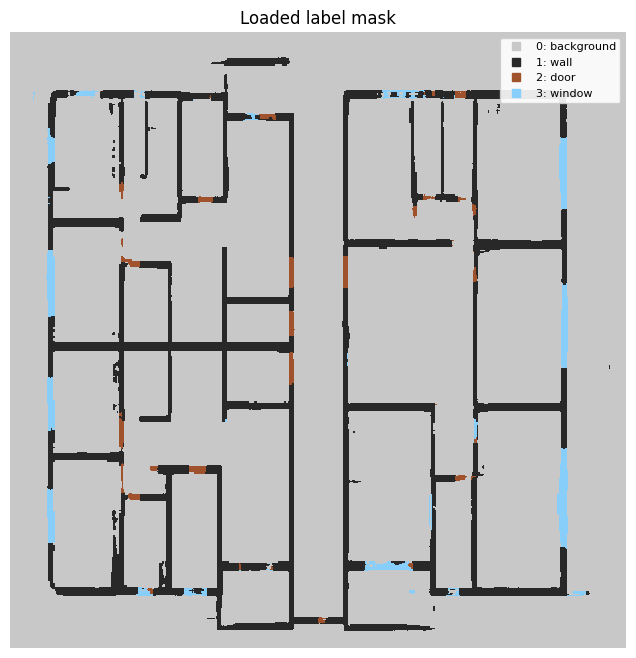

In [4]:
if MASK_FORMAT == "color":
    mask, unmatched_pixels, raw_rgb = load_color_mask_exact(MASK_PATH)
    print(f"Pixels farther than decode tolerance from COLOR_MAP: {int(unmatched_pixels.sum())}")
    if unmatched_pixels.any():
        show_binary(unmatched_pixels, "Pixels that did not match COLOR_MAP exactly")
elif MASK_FORMAT == "label":
    mask = load_label_mask(MASK_PATH)
    raw_rgb = None
else:
    raise ValueError("MASK_FORMAT must be 'color' or 'label'")

fig = show_label_mask(mask, "Loaded label mask")


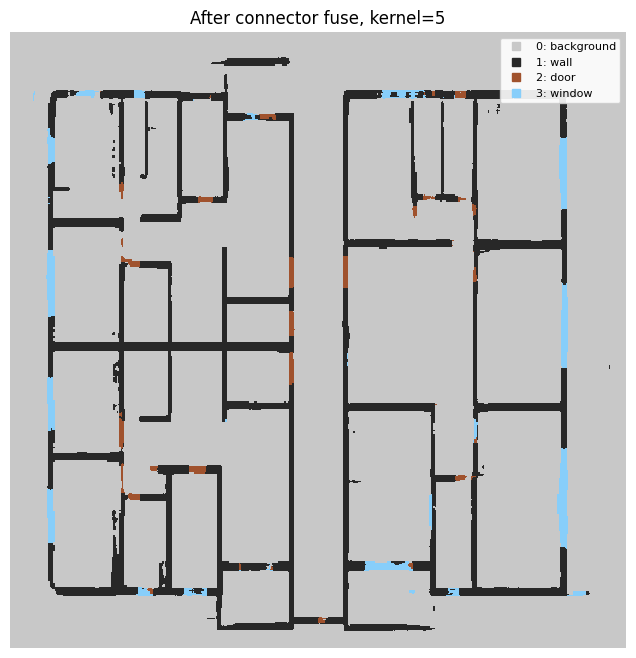

In [5]:
# def fuse_connectors(mask, fuse_kernel_size=5):
#     cleaned = mask.astype(np.int32).copy()
#     kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (fuse_kernel_size, fuse_kernel_size))
#     debug = {}
#     for cid in sorted(CONNECTOR_IDS):
#         before = (cleaned == cid).astype(np.uint8)
#         fused = cv2.morphologyEx(before, cv2.MORPH_CLOSE, kernel)
#         added = (fused > 0) & (cleaned == BACKGROUND_ID)
#         cleaned[added] = cid
#         debug[cid] = {"before": before, "fused": fused, "added": added}
#     return cleaned, debug

def fuse_connectors(mask, fuse_kernel_size=5):
    cleaned = mask.astype(np.int32).copy()
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (fuse_kernel_size, fuse_kernel_size))
    debug = {}

    for cid in sorted(CONNECTOR_IDS):
        before = (cleaned == cid).astype(np.uint8)

        # Important: do not fuse doors with square closing.
        # It can merge nearby perpendicular doors into L-shaped components.
        if cid == DOOR_ID:
            debug[cid] = {"before": before, "fused": before, "added": np.zeros_like(before, dtype=bool)}
            continue

        fused = cv2.morphologyEx(before, cv2.MORPH_CLOSE, kernel)
        added = (fused > 0) & (cleaned == BACKGROUND_ID)
        cleaned[added] = cid
        debug[cid] = {"before": before, "fused": fused, "added": added}

    return cleaned, debug

fused_mask, fuse_debug = fuse_connectors(mask, FUSE_KERNEL_SIZE)
fig = show_label_mask(fused_mask, f"After connector fuse, kernel={FUSE_KERNEL_SIZE}")

Resolved cleanup thresholds: connector_min_area=5px, wall_min_area=13px


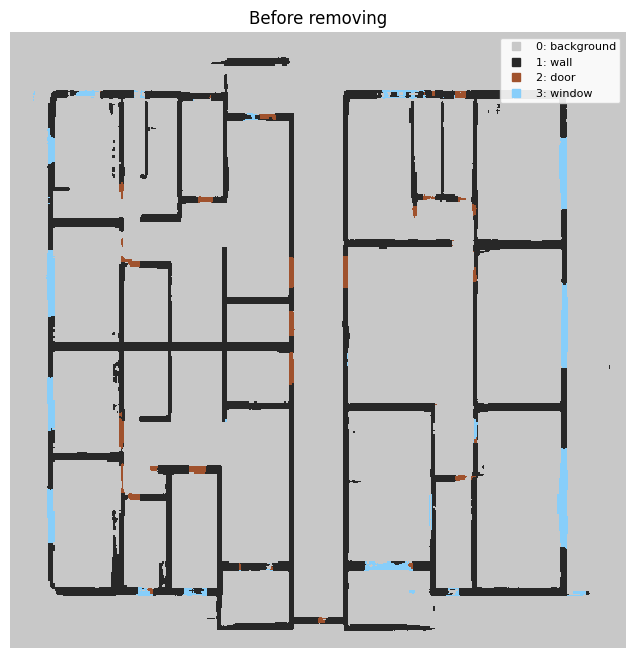

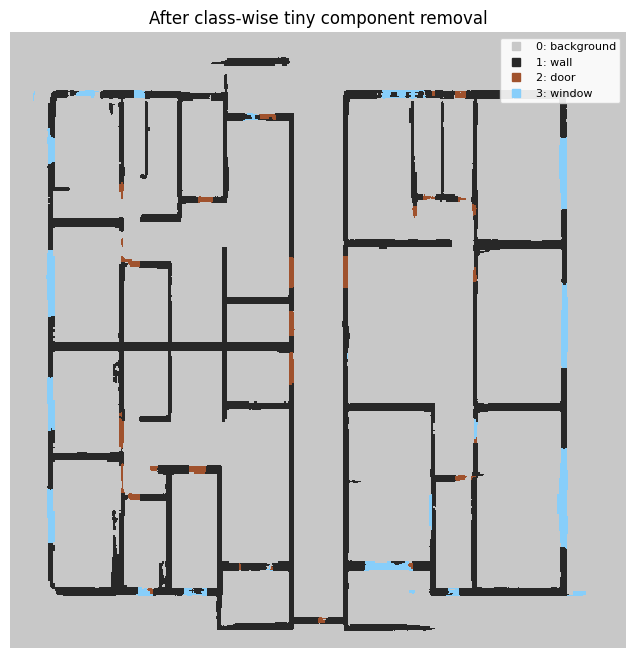

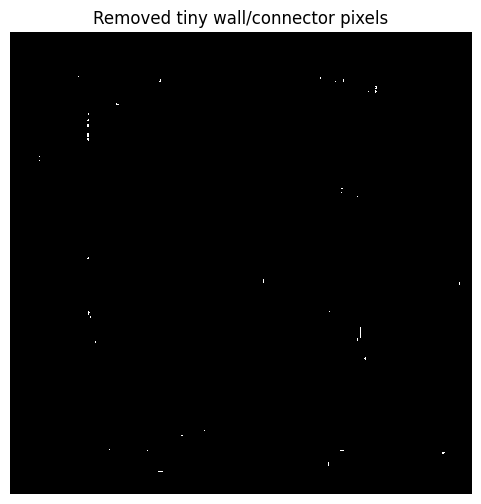

In [6]:
connector_min_area_px = resolve_area_threshold(CONNECTOR_MIN_AREA, fused_mask.shape, minimum=2)
wall_min_area_px = resolve_area_threshold(WALL_MIN_AREA, fused_mask.shape, minimum=10)
print(f"Resolved cleanup thresholds: connector_min_area={connector_min_area_px}px, wall_min_area={wall_min_area_px}px")


def remove_tiny_class_components(mask, connector_min_area=2, wall_min_area=30):
    cleaned = mask.astype(np.int32).copy()
    removed = np.zeros_like(cleaned, dtype=bool)
    summary = []
    min_area_by_class = {
        WALL_ID: wall_min_area,
        DOOR_ID: connector_min_area,
        WINDOW_ID: connector_min_area,
    }

    for cid in [WALL_ID, DOOR_ID, WINDOW_ID]:
        layer = (cleaned == cid).astype(np.uint8)
        n, lbl, stats, cent = cv2.connectedComponentsWithStats(layer, 8)
        for i in range(1, n):
            area = int(stats[i, cv2.CC_STAT_AREA])
            keep = area >= min_area_by_class[cid]
            summary.append({"class_id": cid, "class": LABELS[cid], "component": i, "area_px": area, "kept": keep})
            if not keep:
                drop = lbl == i
                cleaned[drop] = BACKGROUND_ID
                removed |= drop
    
    return cleaned, removed, pd.DataFrame(summary)

despecked_mask, removed_connector_specks, connector_component_table = remove_tiny_class_components(
    fused_mask,
    connector_min_area=connector_min_area_px,
    wall_min_area=wall_min_area_px,
)
show_label_mask(mask, f"Before removing")
show_label_mask(despecked_mask, "After class-wise tiny component removal")
fig = show_binary(removed_connector_specks, "Removed tiny wall/connector pixels", figsize=(6, 6))


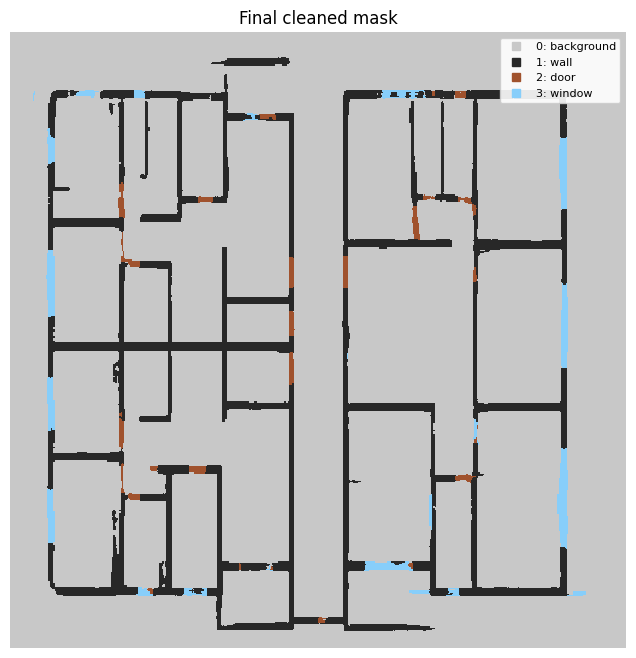

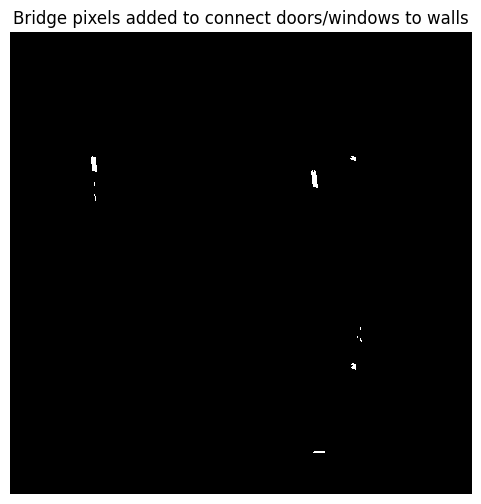

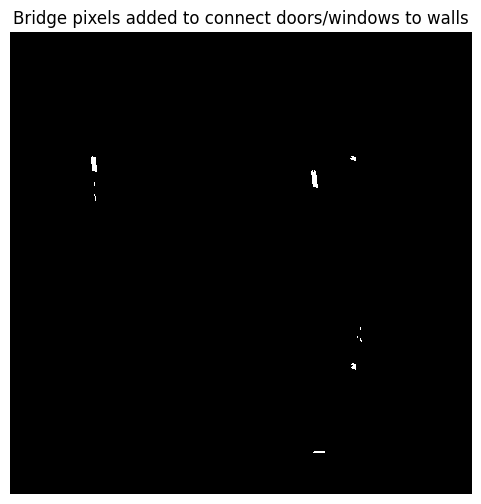

In [7]:
def connect_connectors_to_walls(cleaned, max_gap=20, touch_radius=2, min_pixels=6):
    cleaned = cleaned.astype(np.int32).copy()
    H, W = cleaned.shape
    wall = (cleaned == WALL_ID).astype(np.uint8)
    bridge_mask = np.zeros_like(cleaned, dtype=bool)
    bridge_rows = []

    for cid in sorted(CONNECTOR_IDS):
        n, lbl, stats, _ = cv2.connectedComponentsWithStats((cleaned == cid).astype(np.uint8), 8)
        for i in range(1, n):
            area = int(stats[i, cv2.CC_STAT_AREA])
            if area < min_pixels:
                bridge_rows.append({"class": LABELS[cid], "component": i, "area_px": area, "status": "too_small", "bridges": 0})
                continue

            ys, xs = np.where(lbl == i)
            pts = np.column_stack([xs, ys]).astype(np.float64)
            center = pts.mean(0)
            cov = np.cov((pts - center).T)
            evals, evecs = np.linalg.eigh(cov)
            axis = evecs[:, int(np.argmax(evals))]
            axis = axis / (np.linalg.norm(axis) + 1e-9)
            minor = evecs[:, int(np.argmin(evals))]
            proj_major = (pts - center) @ axis
            proj_minor = (pts - center) @ minor
            thick = max(1, int(round(proj_minor.max() - proj_minor.min())))
            half = thick // 2 + 2
            perp = np.array([-axis[1], axis[0]])
            tips = [(pts[int(np.argmax(proj_major))], +1.0), (pts[int(np.argmin(proj_major))], -1.0)]

            component_bridges = 0
            for tip, sign in tips:
                u = axis * sign
                tx, ty = int(round(tip[0])), int(round(tip[1]))
                y0, y1 = max(0, ty - touch_radius), min(H, ty + touch_radius + 1)
                x0, x1 = max(0, tx - touch_radius), min(W, tx + touch_radius + 1)
                if wall[y0:y1, x0:x1].any():
                    continue

                hit = None
                for step in range(1, max_gap + 1):
                    base = tip + u * step
                    for t in range(-half, half + 1):
                        px = int(round(base[0] + perp[0] * t))
                        py = int(round(base[1] + perp[1] * t))
                        if 0 <= px < W and 0 <= py < H and wall[py, px]:
                            hit = (px, py)
                            break
                    if hit is not None:
                        break

                if hit is not None:
                    line = np.zeros((H, W), np.uint8)
                    cv2.line(line, (tx, ty), hit, 1, thickness=thick)
                    added = (line > 0) & (cleaned == BACKGROUND_ID)
                    cleaned[added] = cid
                    bridge_mask |= added
                    component_bridges += 1

            bridge_rows.append({"class": LABELS[cid], "component": i, "area_px": area, "status": "processed", "bridges": component_bridges})

    return cleaned, bridge_mask, pd.DataFrame(bridge_rows)

if BRIDGE_TO_WALLS:
    cleaned_mask, bridge_added_mask, bridge_table = connect_connectors_to_walls(
        despecked_mask,
        max_gap=BRIDGE_MAX_GAP,
        touch_radius=BRIDGE_TOUCH_RADIUS,
        min_pixels=BRIDGE_MIN_PIXELS,
    )
else:
    cleaned_mask = despecked_mask.copy()
    bridge_added_mask = np.zeros_like(cleaned_mask, dtype=bool)
    bridge_table = pd.DataFrame()

# display(bridge_table)
# print_class_histogram(cleaned_mask, "final cleaned mask")
show_label_mask(cleaned_mask, "Final cleaned mask")
show_binary(bridge_added_mask, "Bridge pixels added to connect doors/windows to walls", figsize=(6, 6))


In [8]:
def bbox4(x, y, w, h):
    return [[int(x), int(y)], [int(x + w), int(y)], [int(x + w), int(y + h)], [int(x), int(y + h)]]


def bbox_contour(blob):
    ys, xs = np.where(blob)
    if xs.size == 0:
        return None
    x0, y0, x1, y1 = int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())
    return [[x0, y0], [x1, y0], [x1, y1], [x0, y1]]


def poly_contour(blob, max_pts=24, min_pts=4):
    cnts, _ = cv2.findContours(blob.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(c, True)
    if peri == 0:
        return None
    eps = 0.001 * peri
    approx = cv2.approxPolyDP(c, eps, True)
    while len(approx) > max_pts and eps < 0.05 * peri:
        eps *= 1.3
        nxt = cv2.approxPolyDP(c, eps, True)
        if len(nxt) < min_pts:
            break
        approx = nxt
    return approx.reshape(-1, 2).tolist()


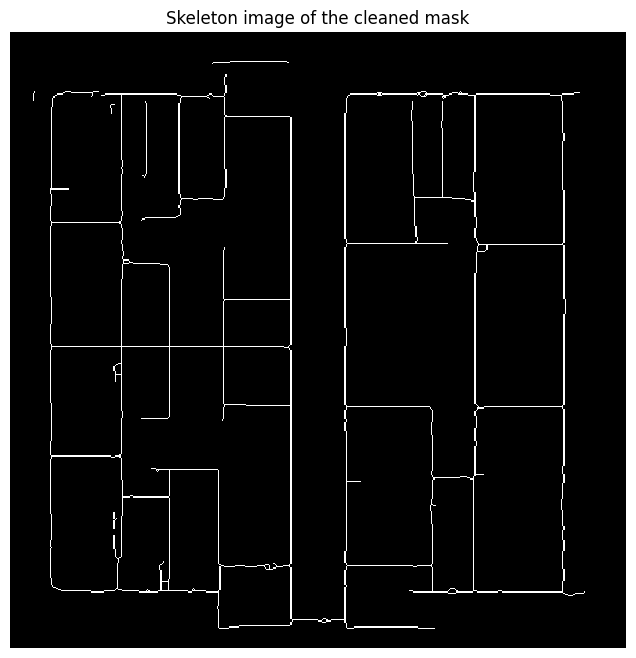

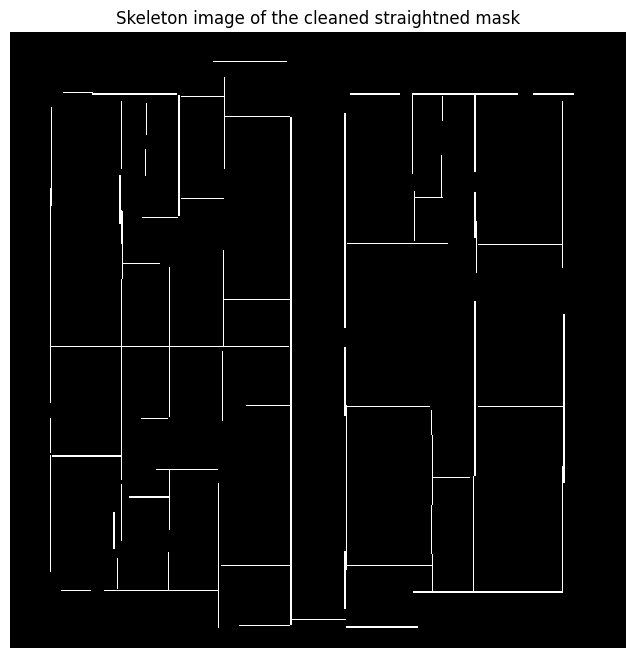

In [9]:
from skimage.morphology import skeletonize

cleaned = cleaned_mask.copy()
H, W = cleaned.shape
barrier_before = np.isin(cleaned, BARRIER_IDS).astype(np.uint8)
barrier = barrier_before.copy()
skeleton = skeletonize(barrier > 0).astype(np.uint8) * 255
    
fig = show_binary(skeleton, "Skeleton image of the cleaned mask")

# Assuming 'skeleton' is your current binary image variable
# Create a blank black canvas of the same size to draw the straight lines on
straightened = np.zeros_like(skeleton)

# 1. Detect line segments
# Adjust 'minLineLength' and 'maxLineGap' based on your image resolution
lines = cv2.HoughLinesP(
    skeleton, 
    rho=1, 
    theta=np.pi / 180, 
    threshold=15,       # Minimum intersections to detect a line
    minLineLength=20,   # Reject lines shorter than this many pixels
    maxLineGap=10       # Max gap between pixels to treat them as a single line
)

# 2. Straighten and snap lines to the nearest axis
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        
        dx = abs(x2 - x1)
        dy = abs(y2 - y1)
        
        if dx > dy:
            # The line is mostly horizontal -> Force Y-coordinates to match
            mean_y = (y1 + y2) // 2
            y1 = y2 = mean_y
        else:
            # The line is mostly vertical -> Force X-coordinates to match
            mean_x = (x1 + x2) // 2
            x1 = x2 = mean_x
            
        # 3. Draw the perfectly straight line back onto the canvas
        # Thickness=1 keeps it identical to your skeleton width
        cv2.line(straightened, (x1, y1), (x2, y2), 255, 1)

fig = show_binary(straightened, "Skeleton image of the cleaned straightned mask")

In [10]:
def extract_rooms_debug(cleaned, min_area=120, contour_mode="poly", seal_ksize=7, min_side=8, min_solidity=0.35):
    H, W = cleaned.shape
    barrier_before = np.isin(cleaned, BARRIER_IDS).astype(np.uint8)
    barrier = barrier_before.copy()

    if seal_ksize and seal_ksize > 1:
        # k = cv2.getStructuringElement(cv2.MORPH_RECT, (seal_ksize, seal_ksize))
        # barrier = cv2.morphologyEx(barrier, cv2.MORPH_CLOSE, k)

        horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (seal_ksize, 1))
        vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, seal_ksize))

        closed_h = cv2.morphologyEx(barrier, cv2.MORPH_CLOSE, horizontal_kernel)
        closed_v = cv2.morphologyEx(barrier, cv2.MORPH_CLOSE, vertical_kernel)

        barrier = cv2.bitwise_or(closed_h, closed_v)

    free = (barrier == 0).astype(np.uint8)
    n, lbl, stats, cent = cv2.connectedComponentsWithStats(free, connectivity=4)

    outside_cc = set()
    for i in range(1, n):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        if x == 0 or y == 0 or x + w >= W or y + h >= H:
            outside_cc.add(i)
    if not outside_cc and n > 1:
        outside_cc.add(max(range(1, n), key=lambda i: stats[i, cv2.CC_STAT_AREA]))

    contour_fn = bbox_contour if contour_mode == "bbox" else poly_contour
    nodes = []
    room_label_map = np.full((H, W), -1, np.int32)
    component_rows = []
    nid = 0
    for i in range(1, n):
        area = int(stats[i, cv2.CC_STAT_AREA])
        bw = int(stats[i, cv2.CC_STAT_WIDTH])
        bh = int(stats[i, cv2.CC_STAT_HEIGHT])
        bbox_area = max(1, bw * bh)
        solidity = area / bbox_area
        is_outside = i in outside_cc
        reject_reason = None
        if is_outside:
            reject_reason = "outside"
        elif area < min_area:
            reject_reason = "too_small"
        elif min(bw, bh) < min_side:
            reject_reason = "too_skinny"
        elif solidity < min_solidity:
            reject_reason = "low_solidity"
        keep = reject_reason is None
        component_rows.append({
            "free_component": i,
            "area_px": area,
            "bbox_x": int(stats[i, cv2.CC_STAT_LEFT]),
            "bbox_y": int(stats[i, cv2.CC_STAT_TOP]),
            "bbox_w": bw,
            "bbox_h": bh,
            "solidity": round(solidity, 3),
            "is_outside": is_outside,
            "kept_as_room": keep,
            "reject_reason": reject_reason,
        })
        if not keep:
            continue
        blob = lbl == i
        contour = contour_fn(blob)
        if contour is None or len(contour) < 3:
            continue
        cx, cy = cent[i]
        nodes.append({
            "id": nid,
            "name": f"room_{nid}",
            "area_px": area,
            "centroid_px": [float(cx), float(cy)],
            "bbox_px": bbox4(stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]),
            "contour": contour,
        })
        room_label_map[blob] = nid
        nid += 1

    outside_mask = np.isin(lbl, list(outside_cc))
    debug = {
        "barrier_before": barrier_before,
        "barrier": barrier,
        "free": free,
        "free_component_map": lbl,
        "outside_component_ids": sorted(outside_cc),
        "component_table": pd.DataFrame(component_rows),
    }
    return nodes, room_label_map, outside_mask, debug


In [11]:
# ============================================================
# 10) Seal sweep - try multiple seal kernels and choose the one with most rooms
# ============================================================
room_min_area_px = resolve_area_threshold(ROOM_MIN_AREA, cleaned_mask.shape, minimum=50)
room_min_side_px = max(8, int(round(min(cleaned_mask.shape) * 0.015)))
print(f"Resolved room filters: room_min_area={room_min_area_px}px, room_min_side={room_min_side_px}px")

seal_list = [SEAL_KSIZE] if SEAL_KSIZE != "auto" else [3, 5, 7, 9] #, 13, 17, 21]
seal_results = []
room_results_by_seal = {}

for seal in seal_list:
    rooms_s, room_label_map_s, outside_mask_s, room_debug_s = extract_rooms_debug(
        cleaned_mask,
        min_area=room_min_area_px,
        contour_mode=CONTOUR_MODE,
        seal_ksize=seal,
        min_side=room_min_side_px,
    )
    rejected = room_debug_s["component_table"]["reject_reason"].notna().sum()
    skinny = (room_debug_s["component_table"]["reject_reason"] == "too_skinny").sum()
    tiny = (room_debug_s["component_table"]["reject_reason"] == "too_small").sum()
    score = len(rooms_s) - 0.15 * rejected - 0.35 * skinny - 0.05 * tiny
    seal_results.append({
        "seal_ksize": seal,
        "rooms": len(rooms_s),
        "free_components": int(room_debug_s["free_component_map"].max()),
        "outside_components": len(room_debug_s["outside_component_ids"]),
        "rejected_components": int(rejected),
        "score": round(float(score), 3),
    })
    room_results_by_seal[seal] = (rooms_s, room_label_map_s, outside_mask_s, room_debug_s)

seal_table = pd.DataFrame(seal_results)
display(seal_table)

best_seal = max(seal_results, key=lambda row: row["score"])["seal_ksize"]
rooms, room_label_map, outside_mask, room_debug = room_results_by_seal[best_seal]
print(f"Best seal kernel: {best_seal}; rooms found: {len(rooms)}")

Resolved room filters: room_min_area=262px, room_min_side=8px


,seal_ksize,rooms,free_components,outside_components,rejected_components,score
0,3,22,27,1,5,21.05
1,5,22,25,1,3,21.45
2,7,22,25,1,3,21.45
3,9,22,25,1,3,21.45


Best seal kernel: 5; rooms found: 22


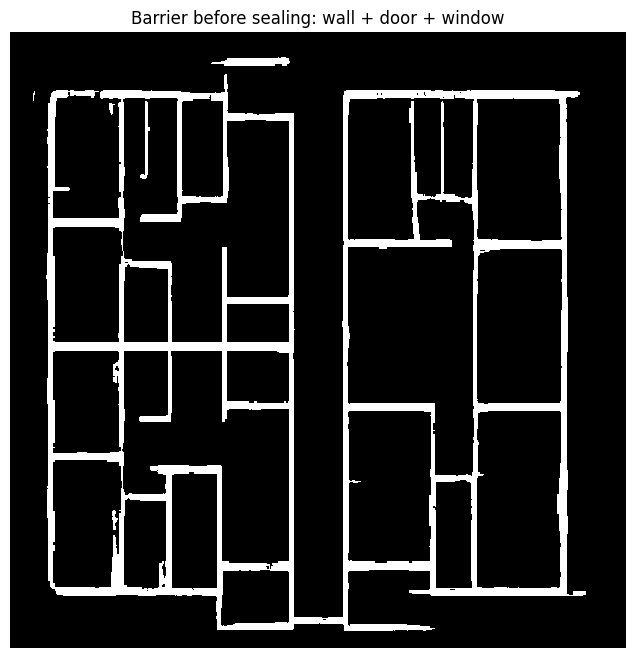

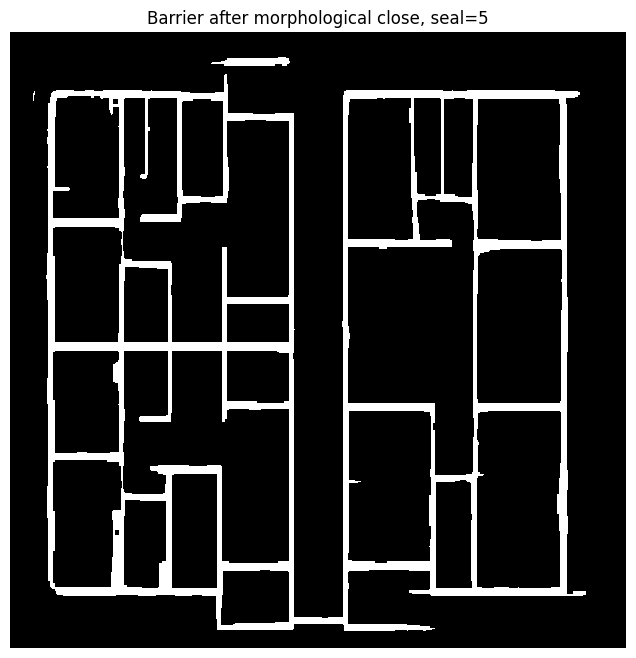

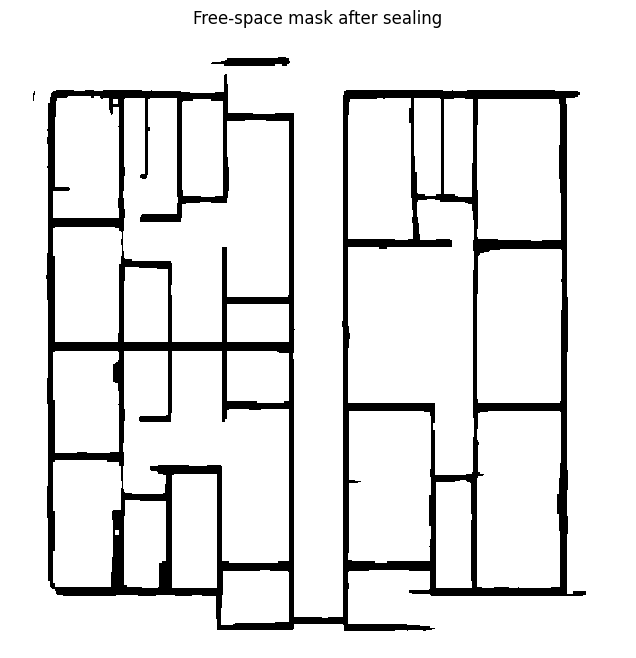

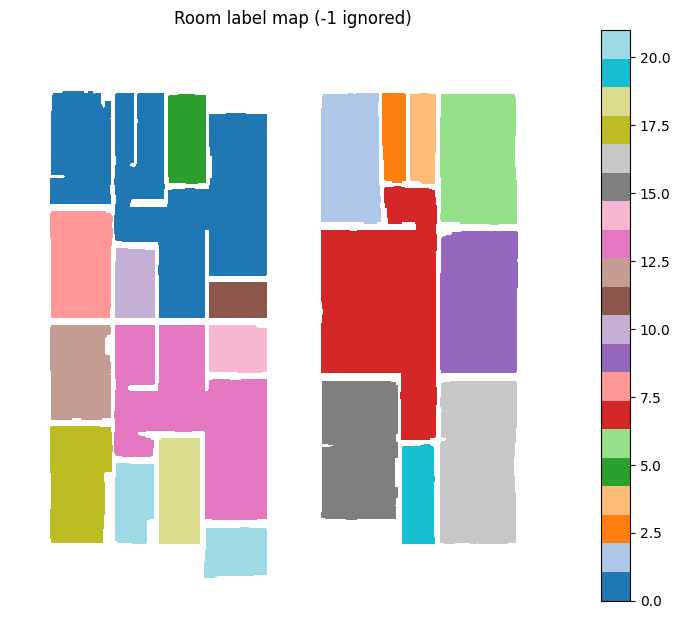

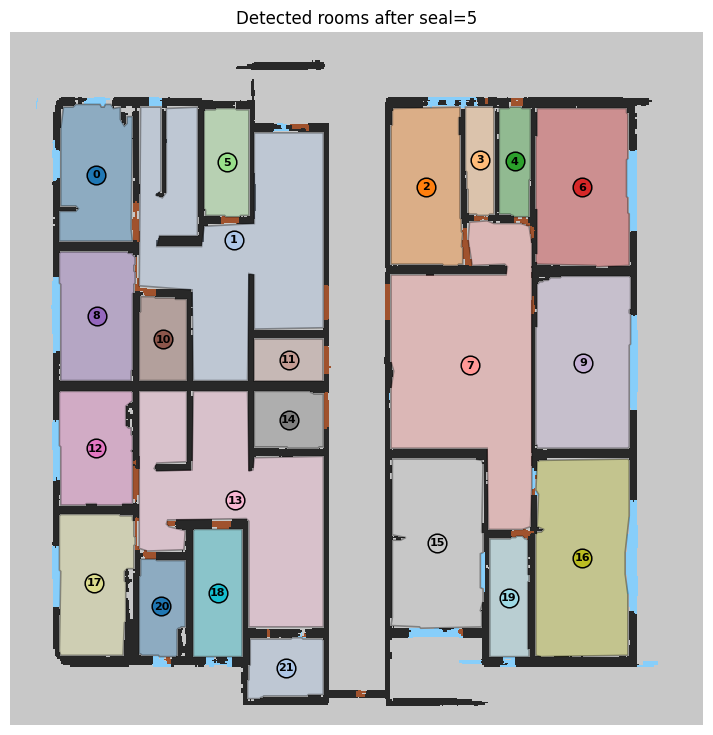

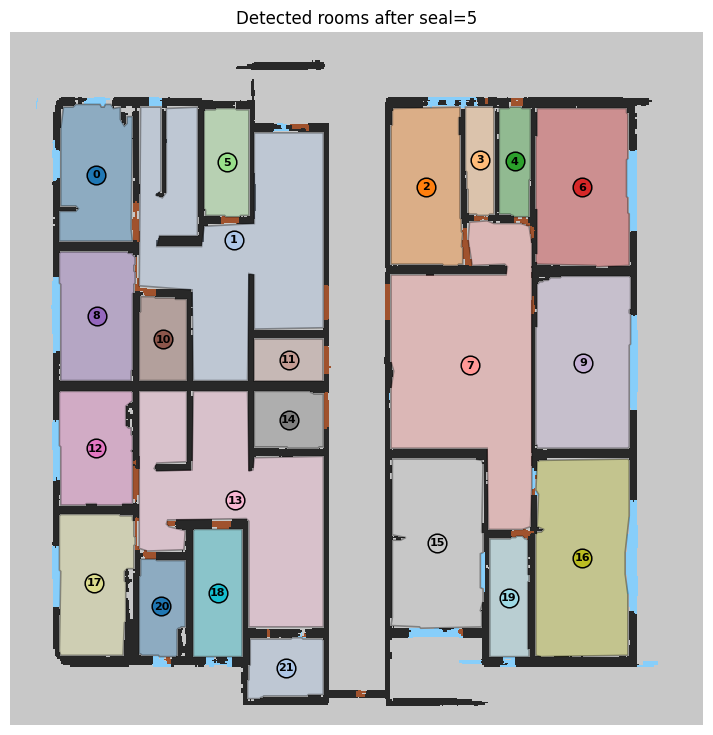

In [12]:
# ============================================================
# 11) Plot selected room-extraction intermediates
# ============================================================
fig = show_binary(room_debug["barrier_before"], "Barrier before sealing: wall + door + window")
fig = show_binary(room_debug["barrier"], f"Barrier after morphological close, seal={best_seal}")
fig = show_binary(room_debug["free"], "Free-space mask after sealing")
show_components(room_label_map, "Room label map (-1 ignored)")
overlay_room_contours(cleaned_mask, rooms, f"Detected rooms after seal={best_seal}")


,component,area_px,bbox_x,bbox_y,bbox_w,bbox_h,fill_ratio,aspect_ratio,horizontal_pixels,vertical_pixels,has_horizontal,has_vertical,suspicious_l_shape
3,4,121,90,125,6,30,0.672,5.00,109,92,True,True,True
7,8,121,334,145,7,28,0.617,4.00,119,109,True,True,True
8,9,97,92,166,16,29,0.209,1.81,62,16,True,False,True
6,7,70,372,137,16,16,0.273,1.00,22,18,True,True,True
20,22,70,370,367,17,8,0.515,2.12,57,60,True,True,True
5,6,57,156,136,13,6,0.731,2.17,52,57,True,True,True
10,11,108,277,186,4,27,1.000,6.75,108,108,True,True,False
9,10,102,232,187,4,26,0.981,6.50,102,102,True,True,False
13,14,99,232,266,4,27,0.917,6.75,95,99,True,True,False
15,16,91,91,321,4,26,0.875,6.50,85,91,True,True,False


Suspicious L-shaped / orthogonal door components: 6


,component,area_px,bbox_x,bbox_y,bbox_w,bbox_h,fill_ratio,aspect_ratio,horizontal_pixels,vertical_pixels,has_horizontal,has_vertical,suspicious_l_shape
3,4,121,90,125,6,30,0.672,5.00,109,92,True,True,True
5,6,57,156,136,13,6,0.731,2.17,52,57,True,True,True
6,7,70,372,137,16,16,0.273,1.00,22,18,True,True,True
7,8,121,334,145,7,28,0.617,4.00,119,109,True,True,True
8,9,97,92,166,16,29,0.209,1.81,62,16,True,False,True
20,22,70,370,367,17,8,0.515,2.12,57,60,True,True,True


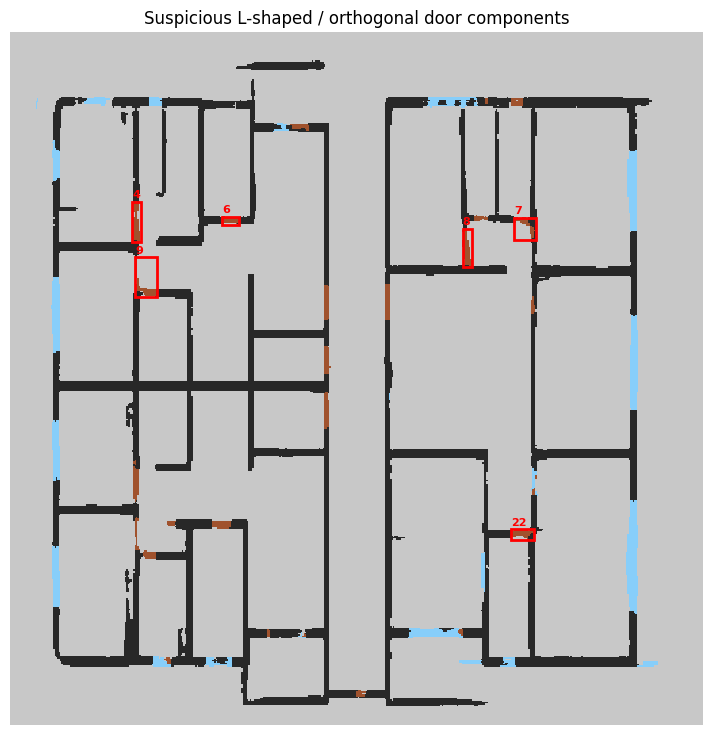

In [13]:
# ============================================================
# 12) Door L-shape / orthogonal merge detection only
# ============================================================
from matplotlib.patches import Rectangle

def detect_l_shaped_doors(cleaned, min_area=2, min_side=6, fill_ratio_threshold=0.55):
    door_layer = (cleaned == DOOR_ID).astype(np.uint8)
    n, lbl, stats, cent = cv2.connectedComponentsWithStats(door_layer, 8)
    rows = []
    suspicious_ids = []

    for i in range(1, n):
        area = int(stats[i, cv2.CC_STAT_AREA])
        x = int(stats[i, cv2.CC_STAT_LEFT])
        y = int(stats[i, cv2.CC_STAT_TOP])
        w = int(stats[i, cv2.CC_STAT_WIDTH])
        h = int(stats[i, cv2.CC_STAT_HEIGHT])
        if area < min_area:
            continue

        blob = (lbl == i).astype(np.uint8)
        fill_ratio = area / max(1, w * h)
        aspect_ratio = max(w, h) / max(1, min(w, h))

        h_len = max(3, min(11, max(3, w // 2)))
        v_len = max(3, min(11, max(3, h // 2)))
        horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (h_len, 1))
        vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, v_len))
        horizontal_part = cv2.morphologyEx(blob, cv2.MORPH_OPEN, horizontal_kernel)
        vertical_part = cv2.morphologyEx(blob, cv2.MORPH_OPEN, vertical_kernel)

        horizontal_pixels = int(horizontal_part.sum())
        vertical_pixels = int(vertical_part.sum())
        has_horizontal = horizontal_pixels >= max(3, 0.20 * area)
        has_vertical = vertical_pixels >= max(3, 0.20 * area)

        is_boxy = w >= min_side and h >= min_side
        low_fill = fill_ratio < fill_ratio_threshold
        orthogonal_parts = has_horizontal and has_vertical and fill_ratio < 0.75
        suspicious_l_shape = is_boxy and (low_fill or orthogonal_parts)

        if suspicious_l_shape:
            suspicious_ids.append(i)

        rows.append({
            "component": i,
            "area_px": area,
            "bbox_x": x,
            "bbox_y": y,
            "bbox_w": w,
            "bbox_h": h,
            "fill_ratio": round(fill_ratio, 3),
            "aspect_ratio": round(aspect_ratio, 2),
            "horizontal_pixels": horizontal_pixels,
            "vertical_pixels": vertical_pixels,
            "has_horizontal": has_horizontal,
            "has_vertical": has_vertical,
            "suspicious_l_shape": suspicious_l_shape,
        })

    return pd.DataFrame(rows), lbl, suspicious_ids

door_shape_table, door_component_map, suspicious_l_door_ids = detect_l_shaped_doors(
    cleaned_mask,
    min_area=connector_min_area_px,
)

suspicious_l_door_table = door_shape_table[door_shape_table["suspicious_l_shape"]].copy()
display(door_shape_table.sort_values(["suspicious_l_shape", "area_px"], ascending=[False, False]))
print(f"Suspicious L-shaped / orthogonal door components: {len(suspicious_l_door_ids)}")
display(suspicious_l_door_table)

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(mask_to_rgb(cleaned_mask), interpolation="nearest")
for _, row in suspicious_l_door_table.iterrows():
    rect = Rectangle(
        (row["bbox_x"], row["bbox_y"]),
        row["bbox_w"],
        row["bbox_h"],
        fill=False,
        edgecolor="red",
        linewidth=2,
    )
    ax.add_patch(rect)
    ax.text(row["bbox_x"], row["bbox_y"] - 3, int(row["component"]), color="red", fontsize=8, weight="bold")
ax.set_title("Suspicious L-shaped / orthogonal door components")
ax.axis("off")
plt.show()


In [14]:
def split_l_door_blob(blob, min_pixels=3):
    """
    Split one L-shaped door blob into horizontal and vertical door pieces.
    If it is not L-shaped, return the original blob.
    """
    ys, xs = np.where(blob)
    if xs.size == 0:
        return [("unknown", blob)]

    h, w = blob.shape

    # Adaptive kernels based on component size
    bw = xs.max() - xs.min() + 1
    bh = ys.max() - ys.min() + 1

    h_len = max(3, min(15, bw // 2))
    v_len = max(3, min(15, bh // 2))

    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (h_len, 1))
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, v_len))

    horizontal = cv2.morphologyEx(
        blob.astype(np.uint8),
        cv2.MORPH_OPEN,
        h_kernel
    ).astype(bool)

    vertical = cv2.morphologyEx(
        blob.astype(np.uint8),
        cv2.MORPH_OPEN,
        v_kernel
    ).astype(bool)

    pieces = []

    if horizontal.sum() >= min_pixels:
        pieces.append(("horizontal", horizontal))

    if vertical.sum() >= min_pixels:
        pieces.append(("vertical", vertical))

    # If splitting failed, keep original component
    if len(pieces) < 2:
        return [("unknown", blob)]

    return pieces

,class_id,class,component,area_px,kept,split,piece_orientation
8,2,door,4,121,True,False,NaN
20,2,door,8,121,True,False,NaN
21,2,door,8,119,True,True,horizontal
9,2,door,4,109,True,True,horizontal
22,2,door,8,109,True,True,vertical
...,...,...,...,...,...,...,...
109,3,window,17,82,True,False,NaN
110,3,window,17,82,True,False,unknown
117,3,window,21,80,True,False,NaN
118,3,window,21,80,True,False,unknown


,id,type,label_id,orientation,centroid_px,source_component
0,0,door,2,unknown,"[351.5, 50.5]",1
1,1,door,2,horizontal,"[375.0, 51.528301886792455]",2
2,2,door,2,vertical,"[374.0, 51.57692307692308]",2
3,3,door,2,horizontal,"[213.2608695652174, 69.30434782608695]",3
4,4,door,2,vertical,"[213.98, 69.54]",3
...,...,...,...,...,...,...
68,68,window,3,unknown,"[110.47297297297297, 465.2162162162162]",20
69,69,window,3,unknown,"[153.3375, 465.2875]",21
70,70,window,3,unknown,"[368.2142857142857, 465.1607142857143]",22
71,71,window,3,unknown,"[340.1458333333333, 464.9583333333333]",23


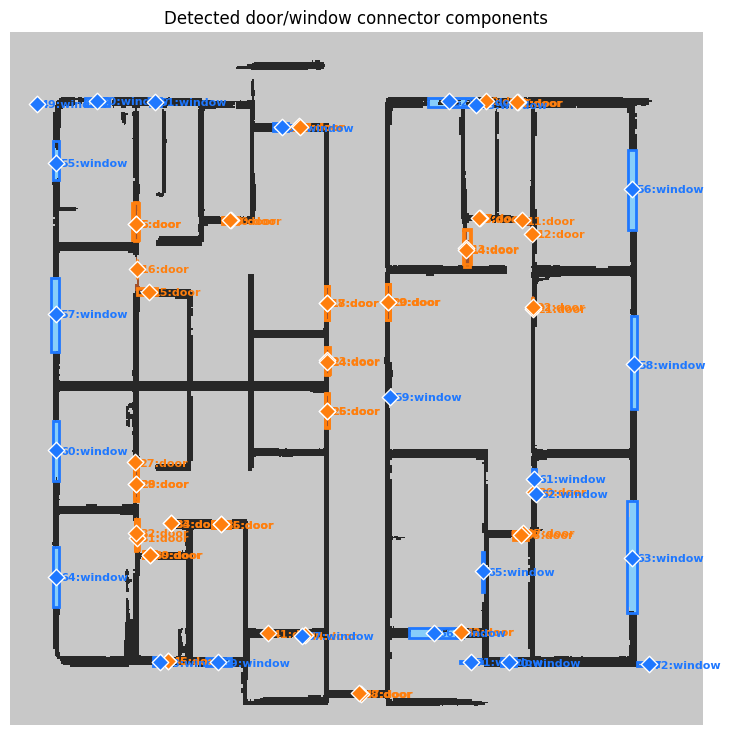

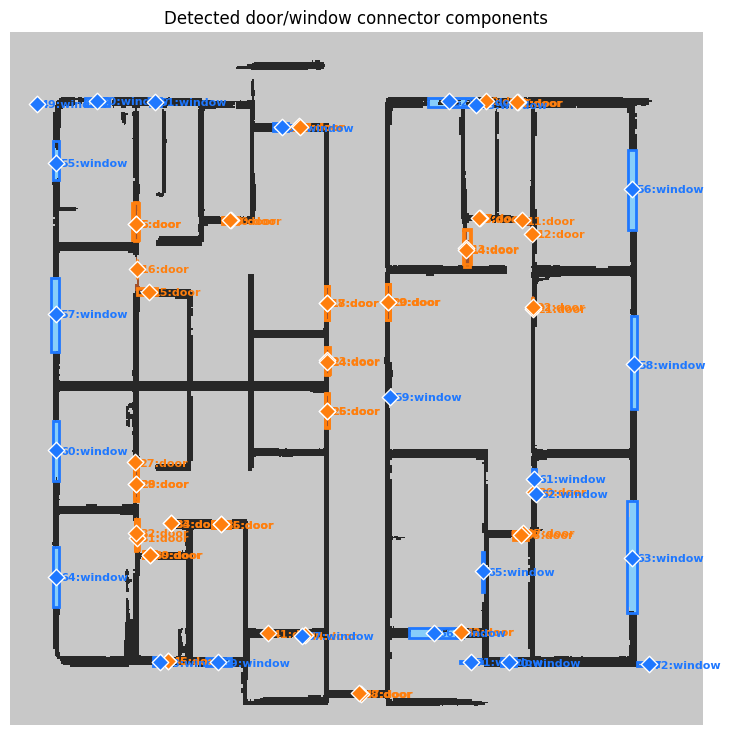

In [15]:
# ============================================================
# 12) Connector extraction
# ============================================================
# def extract_connectors_debug(cleaned, min_area=2):
#     conns = []
#     rows = []
#     cnt = 0
#     for cls in sorted(CONNECTOR_IDS):
#         layer = (cleaned == cls).astype(np.uint8)
#         n, lbl, stats, cent = cv2.connectedComponentsWithStats(layer, 8)
#         for i in range(1, n):
#             area = int(stats[i, cv2.CC_STAT_AREA])
#             keep = area >= min_area
#             rows.append({"class_id": cls, "class": LABELS[cls], "component": i, "area_px": area, "kept": keep})
#             if not keep:
#                 continue
#             blob = lbl == i
#             contour = bbox_contour(blob)
#             if contour is None:
#                 continue
#             cx, cy = cent[i]
#             conns.append({
#                 "id": cnt,
#                 "type": LABELS[cls],
#                 "label_id": int(cls),
#                 "centroid_px": [float(cx), float(cy)],
#                 "contour": contour,
#                 "_mask": blob,
#             })
#             cnt += 1
#     return conns, pd.DataFrame(rows)

def extract_connectors_debug(cleaned, min_area=2):
    conns = []
    rows = []
    cnt = 0

    for cls in sorted(CONNECTOR_IDS):
        layer = (cleaned == cls).astype(np.uint8)
        n, lbl, stats, cent = cv2.connectedComponentsWithStats(layer, 8)

        for i in range(1, n):
            area = int(stats[i, cv2.CC_STAT_AREA])
            keep = area >= min_area

            rows.append({
                "class_id": cls,
                "class": LABELS[cls],
                "component": i,
                "area_px": area,
                "kept": keep,
                "split": False,
                "piece_orientation": None,
            })

            if not keep:
                continue

            blob = lbl == i

            # Split only door components.
            # Windows remain as normal connected components.
            if cls == DOOR_ID:
                pieces = split_l_door_blob(blob, min_pixels=min_area)
            else:
                pieces = [("unknown", blob)]

            for orientation, piece_blob in pieces:
                piece_area = int(piece_blob.sum())

                if piece_area < min_area:
                    continue

                contour = bbox_contour(piece_blob)
                if contour is None:
                    continue

                ys, xs = np.where(piece_blob)
                cx = float(xs.mean())
                cy = float(ys.mean())

                conns.append({
                    "id": cnt,
                    "type": LABELS[cls],
                    "label_id": int(cls),
                    "orientation": orientation,
                    "centroid_px": [cx, cy],
                    "contour": contour,
                    "_mask": piece_blob,
                    "source_component": int(i),
                })

                rows.append({
                    "class_id": cls,
                    "class": LABELS[cls],
                    "component": i,
                    "area_px": piece_area,
                    "kept": True,
                    "split": len(pieces) > 1,
                    "piece_orientation": orientation,
                })

                cnt += 1

    return conns, pd.DataFrame(rows)

connectors, connector_extract_table = extract_connectors_debug(cleaned_mask, connector_min_area_px)
display(connector_extract_table.sort_values(["class_id", "area_px"], ascending=[True, False]).head(100))
display(pd.DataFrame([{k: v for k, v in c.items() if k != "_mask" and k != "contour"} for c in connectors]))
overlay_connectors(cleaned_mask, connectors, "Detected door/window connector components")


In [16]:
# ============================================================
# 13) Build room-connector edges
# ============================================================
def touching_rooms(conn_mask, room_label_map, outside_mask, tolerance):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * tolerance + 1, 2 * tolerance + 1))
    grown = cv2.dilate(conn_mask.astype(np.uint8), k).astype(bool)
    touches_outside = bool((grown & outside_mask).any())
    region = room_label_map[grown]
    region = region[region >= 0]
    if region.size == 0:
        return [], touches_outside, grown
    ids, counts = np.unique(region, return_counts=True)
    ordered = ids[np.argsort(-counts)].tolist()
    return ordered, touches_outside, grown


def connector_opposite_side_rooms(conn_mask, room_label_map, outside_mask, tolerance):
    ys, xs = np.where(conn_mask)
    if xs.size < 2:
        rooms, outside, grown = touching_rooms(conn_mask, room_label_map, outside_mask, tolerance)
        return rooms, outside, grown

    H, W = conn_mask.shape
    pts = np.column_stack([xs, ys]).astype(np.float64)
    center = pts.mean(axis=0)
    cov = np.cov((pts - center).T)
    evals, evecs = np.linalg.eigh(cov)
    axis = evecs[:, int(np.argmax(evals))]
    axis = axis / (np.linalg.norm(axis) + 1e-9)
    normal = np.array([-axis[1], axis[0]])

    grown = np.zeros_like(conn_mask, dtype=bool)
    side_rooms = []
    touches_outside = False
    for sign in (-1, 1):
        probe = np.zeros_like(conn_mask, dtype=np.uint8)
        for step in range(1, tolerance + 1):
            shifted = pts + normal * sign * step
            px = np.rint(shifted[:, 0]).astype(int)
            py = np.rint(shifted[:, 1]).astype(int)
            ok = (0 <= px) & (px < W) & (0 <= py) & (py < H)
            probe[py[ok], px[ok]] = 1
        grown |= probe.astype(bool)
        touches_outside = touches_outside or bool((probe.astype(bool) & outside_mask).any())
        region = room_label_map[probe.astype(bool)]
        region = region[region >= 0]
        if region.size:
            ids, counts = np.unique(region, return_counts=True)
            side_rooms.append(int(ids[np.argmax(counts)]))

    rooms = []
    for rid in side_rooms:
        if rid not in rooms:
            rooms.append(rid)
    if len(rooms) == 0:
        rooms, touches_outside, grown = touching_rooms(conn_mask, room_label_map, outside_mask, tolerance)
    return rooms, touches_outside, grown


def build_edges_debug(room_label_map, outside_mask, connectors, tolerance):
    edges = []
    rows = []
    grown_by_connector = {}
    for eid, c in enumerate(connectors):
        rooms_touched, outside, grown = connector_opposite_side_rooms(c["_mask"], room_label_map, outside_mask, tolerance)
        grown_by_connector[eid] = grown
        edge = {
            "id": eid,
            "type": c["type"],
            "label_id": c["label_id"],
            "centroid_px": c["centroid_px"],
            "contour": c["contour"],
            "from": None,
            "to": None,
        }
        if c["label_id"] == WINDOW_ID:
            if len(rooms_touched) >= 1 and outside:
                edge["from"] = int(rooms_touched[0])
                edge["to"] = OUTSIDE_ID
        elif len(rooms_touched) >= 2:
            edge["from"], edge["to"] = int(rooms_touched[0]), int(rooms_touched[1])
        elif len(rooms_touched) == 1:
            edge["from"] = int(rooms_touched[0])
            edge["to"] = OUTSIDE_ID if outside else None
        edges.append(edge)
        rows.append({
            "edge_id": eid,
            "type": c["type"],
            "rooms_touched_ordered": rooms_touched,
            "touches_outside": outside,
            "from": edge["from"],
            "to": edge["to"],
        })
    return edges, pd.DataFrame(rows), grown_by_connector

effective_tolerance = max(MATCH_TOLERANCE, int(best_seal) // 2 + 4)
edges, edge_table, grown_by_connector = build_edges_debug(room_label_map, outside_mask, connectors, effective_tolerance)
print(f"Effective connector-room tolerance: {effective_tolerance}")
display(edge_table)


Effective connector-room tolerance: 6


,edge_id,type,rooms_touched_ordered,touches_outside,from,to
0,0,door,[3],True,3.0,-1.0
1,1,door,[4],True,4.0,-1.0
2,2,door,[4],True,4.0,-1.0
3,3,door,[1],True,1.0,-1.0
4,4,door,[1],True,1.0,-1.0
...,...,...,...,...,...,...
68,68,window,[20],True,20.0,-1.0
69,69,window,[18],True,18.0,-1.0
70,70,window,[19],True,19.0,-1.0
71,71,window,[],True,NaN,NaN


In [17]:
# # ============================================================
# # 14) Plot connector matching dilation for each connector
# # ============================================================
# for conn in connectors:
#     eid = conn["id"]
#     grown = grown_by_connector[eid]
#     fig, ax = plt.subplots(figsize=(7, 7))
#     ax.imshow(mask_to_rgb(cleaned_mask), interpolation="nearest")
#     ax.imshow(np.ma.masked_where(~grown, grown), cmap="autumn", alpha=0.35, interpolation="nearest")
#     ax.imshow(np.ma.masked_where(room_label_map < 0, room_label_map), cmap="tab20", alpha=0.25, interpolation="nearest")
#     cx, cy = conn["centroid_px"]
#     ax.scatter([cx], [cy], s=90, marker="D", c="white", edgecolors="black")
#     row = edge_table.loc[edge_table["edge_id"] == eid].iloc[0].to_dict()
#     ax.set_title(f"Connector {eid} {conn['type']} grown by tolerance={effective_tolerance}; from={row['from']} to={row['to']}")
#     ax.axis("off")
#     plt.show()


Final internal graph: 22 rooms, 63 edges


,id,name,area_px,centroid_px,bbox_px,contour
0,0,room_0,5323,"[63.18823971444674, 104.83186173210595]","[[36, 53], [91, 53], [91, 155], [36, 155]]","[[39, 55], [37, 71], [37, 128], [48, 128], [50..."
1,1,room_1,17740,"[165.0052423900789, 153.06228861330328]","[[94, 55], [232, 55], [232, 258], [94, 258]]","[[96, 55], [95, 187], [134, 190], [135, 257], ..."
2,2,room_2,6094,"[306.8288480472596, 113.95454545454545]","[[281, 55], [335, 55], [335, 173], [281, 173]]","[[283, 56], [282, 58], [282, 68], [281, 69], [..."
3,3,room_3,1716,"[346.81293706293707, 93.92715617715618]","[[336, 55], [358, 55], [358, 136], [336, 136]]","[[336, 55], [336, 102], [337, 103], [337, 115]..."
4,4,room_4,1905,"[372.4062992125984, 95.00157480314961]","[[361, 55], [385, 55], [385, 137], [361, 137]]","[[361, 56], [361, 134], [369, 134], [370, 135]..."
5,5,room_5,2706,"[159.55210643015522, 95.8869179600887]","[[143, 56], [177, 56], [177, 137], [143, 137]]","[[144, 57], [143, 58], [143, 130], [144, 131],..."
6,6,room_6,8015,"[422.34622582657516, 114.15246412975671]","[[388, 56], [458, 56], [458, 174], [388, 174]]","[[389, 56], [389, 76], [388, 77], [388, 130], ..."
7,7,room_7,16923,"[339.5500206819122, 245.72168055309342]","[[281, 139], [386, 139], [386, 368], [281, 368]]","[[339, 140], [338, 153], [341, 172], [365, 171..."
8,8,room_8,5238,"[63.548300878197786, 209.05154639175257]","[[36, 162], [93, 162], [93, 258], [36, 258]]","[[37, 162], [36, 163], [36, 185], [37, 186], [..."
9,9,room_9,8920,"[422.98329596412555, 243.77724215246636]","[[388, 180], [459, 180], [459, 308], [388, 308]]","[[391, 184], [389, 186], [389, 217], [388, 218..."


,id,type,label_id,centroid_px,contour,from,to
0,0,door,2,"[351.5, 50.5]","[[351, 49], [352, 49], [352, 52], [351, 52]]",3,-1.0
1,1,door,2,"[375.0, 51.528301886792455]","[[371, 49], [379, 49], [379, 54], [371, 54]]",4,-1.0
2,2,door,2,"[374.0, 51.57692307692308]","[[370, 49], [378, 49], [378, 54], [370, 54]]",4,-1.0
3,3,door,2,"[213.2608695652174, 69.30434782608695]","[[207, 68], [220, 68], [220, 71], [207, 71]]",1,-1.0
4,4,door,2,"[213.98, 69.54]","[[208, 68], [220, 68], [220, 72], [208, 72]]",1,-1.0
...,...,...,...,...,...,...,...
58,64,window,3,"[33.52401746724891, 401.96069868995636]","[[31, 380], [36, 380], [36, 424], [31, 424]]",17,-1.0
59,66,window,3,"[312.66101694915255, 443.51271186440675]","[[294, 440], [334, 440], [334, 447], [294, 447]]",15,-1.0
60,68,window,3,"[110.47297297297297, 465.2162162162162]","[[105, 461], [118, 461], [118, 468], [105, 468]]",20,-1.0
61,69,window,3,"[153.3375, 465.2875]","[[144, 462], [163, 462], [163, 468], [144, 468]]",18,-1.0


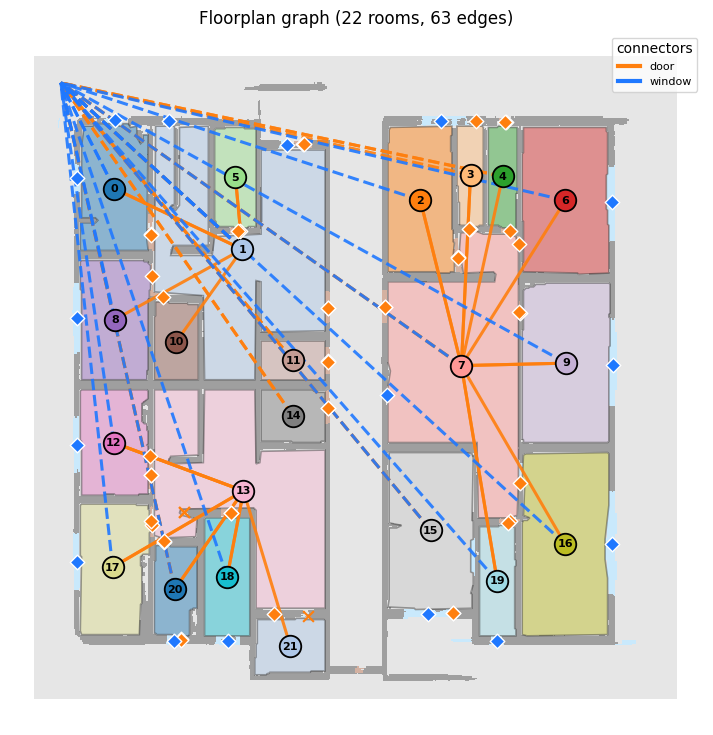

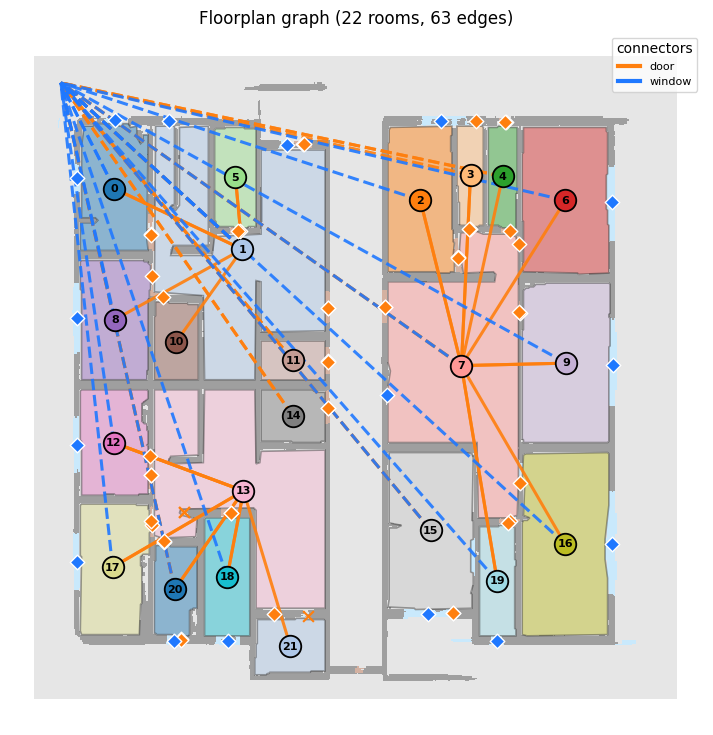

In [18]:
# ============================================================
# 15) Clean graph and plot final internal graph
# ============================================================
def clean_graph(graph, keep_outside=True):
    graph = dict(graph)
    if keep_outside:
        graph["edges"] = [e for e in graph["edges"] if e["from"] is not None]
    else:
        graph["edges"] = [e for e in graph["edges"] if e["from"] is not None and e["to"] is not None and e["to"] != OUTSIDE_ID]
    return graph


def plot_graph(graph, image_size=None, figsize=(9, 9), show_mask=True):
    nodes, edges = graph["nodes"], graph["edges"]
    cleaned = graph.get("cleaned_mask")
    if image_size is None and cleaned is not None:
        image_size = cleaned.shape
    H, W = image_size if image_size else (512, 512)
    edge_colors = {DOOR_ID: "#ff7f0e", WINDOW_ID: "#1f78ff"}
    edge_names = {DOOR_ID: "door", WINDOW_ID: "window"}
    cmap = plt.colormaps["tab20"]

    fig, ax = plt.subplots(figsize=figsize)
    if show_mask and cleaned is not None:
        ax.imshow(mask_to_rgb(cleaned), alpha=0.45, interpolation="nearest")

    outside_xy = (W * 0.04, H * 0.04)
    node_xy = {OUTSIDE_ID: outside_xy}
    for n in nodes:
        cx, cy = n["centroid_px"]
        node_xy[n["id"]] = (cx, cy)
        color = cmap(n["id"] % 20)
        if n.get("contour") and len(n["contour"]) >= 3:
            ax.add_patch(MplPolygon(n["contour"], closed=True, facecolor=color, edgecolor="#333333", alpha=0.45, linewidth=1.2))
        ax.scatter([cx], [cy], s=240, color=color, edgecolors="black", zorder=5, linewidths=1.3)
        ax.text(cx, cy, str(n["id"]), ha="center", va="center", fontsize=8, fontweight="bold", zorder=6)

    for e in edges:
        a = node_xy.get(e.get("from"))
        b = node_xy.get(e.get("to"))
        color = edge_colors.get(e["label_id"], "#555555")
        if a is None:
            continue
        if b is None:
            mx, my = e["centroid_px"]
            ax.scatter([mx], [my], s=60, marker="x", c=color, zorder=7)
            continue
        is_out = e.get("to") == OUTSIDE_ID
        ax.plot([a[0], b[0]], [a[1], b[1]], color=color, lw=2.2, zorder=4, solid_capstyle="round", linestyle="--" if is_out else "-", alpha=0.9)
        mx, my = e["centroid_px"]
        ax.scatter([mx], [my], s=55, marker="D", c=color, edgecolors="white", linewidths=1, zorder=7)

    handles = [Line2D([0], [0], color=c, lw=3, label=edge_names[k]) for k, c in edge_colors.items()]
    ax.legend(handles=handles, title="connectors", loc="upper right", fontsize=8)
    ax.set_xlim(-20, W + 20)
    ax.set_ylim(H + 20, -20)
    ax.set_aspect("equal")
    ax.set_title(f"Floorplan graph ({len(nodes)} rooms, {len(edges)} edges)")
    ax.axis("off")
    plt.show()
    return fig

graph = {
    "nodes": rooms,
    "edges": edges,
    "cleaned_mask": cleaned_mask,
    "outside_mask": outside_mask,
}
graph = clean_graph(graph, keep_outside=KEEP_OUTSIDE_EDGES)
print(f"Final internal graph: {len(graph['nodes'])} rooms, {len(graph['edges'])} edges")
display(pd.DataFrame(graph["nodes"]))
display(pd.DataFrame(graph["edges"]))
plot_graph(graph, image_size=mask.shape, show_mask=True)


In [19]:
# ============================================================
# 16) Export schema helpers
# ============================================================
def round_pt(p):
    return [int(round(p[0])), int(round(p[1]))]


def to_export_schema(graph, image_size, sample_id="sample", scale_px_per_ft=None):
    H, W = image_size
    rooms_out = graph["nodes"]
    edges_out_internal = graph["edges"]
    N = len(rooms_out)

    BUILDING_ID = 0
    room_eid = {r["id"]: r["id"] + 1 for r in rooms_out}
    needs_exterior = any(e.get("to") == OUTSIDE_ID for e in edges_out_internal)
    EXTERIOR_ID = (N + 1) if needs_exterior else None
    full_poly = [[0, 0], [W, 0], [W, H], [0, H]]

    nodes_out = [{
        "id": BUILDING_ID,
        "hierarchy_id": "0",
        "name": "building",
        "label_id": None,
        "type": "building",
        "parent_id": None,
        "bbox_px": full_poly,
        "polygon_px": full_poly,
    }]

    for k, r in enumerate(rooms_out, start=1):
        nodes_out.append({
            "id": room_eid[r["id"]],
            "hierarchy_id": f"0.{k}",
            "name": r.get("name", f"room_{k}"),
            "label_id": None,
            "type": "room",
            "parent_id": BUILDING_ID,
            "area_px": int(r.get("area_px", 0)),
            "centroid_px": round_pt(r["centroid_px"]),
            "bbox_px": r.get("bbox_px"),
            "polygon_px": r.get("contour"),
        })

    if needs_exterior:
        nodes_out.append({
            "id": EXTERIOR_ID,
            "hierarchy_id": f"0.{N + 1}",
            "name": "exterior",
            "label_id": BACKGROUND_ID,
            "type": "exterior",
            "parent_id": None,
            "bbox_px": full_poly,
            "polygon_px": None,
        })

    schema_edges, warnings = [], []
    for r in rooms_out:
        schema_edges.append({"from_id": BUILDING_ID, "to_id": room_eid[r["id"]], "relationship": "contains"})

    for e in edges_out_internal:
        if e["from"] is None:
            warnings.append("connector touched no room (dropped)")
            continue
        ctype = LABELS.get(e["label_id"], "connector")
        center = round_pt(e["centroid_px"])
        if e["to"] == OUTSIDE_ID:
            rel = "entry_to" if e["label_id"] == DOOR_ID else "opens_to"
            efrom, eto = room_eid[e["from"]], EXTERIOR_ID
        elif e["to"] is None:
            continue
        else:
            rel = "connected_to"
            efrom, eto = room_eid[e["from"]], room_eid[e["to"]]
        schema_edges.append({"from_id": efrom, "to_id": eto, "relationship": rel, "connection_type": ctype, "center_px": center})

    present = sorted({int(v) for v in np.unique(graph["cleaned_mask"])})
    return {
        "sample_id": sample_id,
        "graph_type": "room_connectivity_graph_4class",
        "apartment_mix": [],
        "image_size_wh": [int(W), int(H)],
        "scale_px_per_ft": scale_px_per_ft,
        "nodes": nodes_out,
        "edges": schema_edges,
        "unique_label_ids": present,
        "unique_classes": [LABELS.get(i, str(i)) for i in present],
        "rule_validation": {
            "valid": N > 0,
            "errors": [] if N > 0 else ["no rooms detected"],
            "warnings": sorted(set(warnings)),
        },
        "project_type": "layout_graph",
        "units": [],
        "rooms": [n["id"] for n in nodes_out if n["type"] == "room"],
        "unit_masks": [],
        "access_points": [e for e in schema_edges if e.get("relationship") in ("entry_to", "opens_to")],
    }


In [20]:
# ============================================================
# 17) Create export JSON object and inspect it before saving
# ============================================================
export_data = to_export_schema(graph, image_size=mask.shape, sample_id=SAMPLE_ID)
print(json.dumps({
    "sample_id": export_data["sample_id"],
    "image_size_wh": export_data["image_size_wh"],
    "node_count": len(export_data["nodes"]),
    "edge_count": len(export_data["edges"]),
    "rule_validation": export_data["rule_validation"],
}, indent=2))
display(pd.DataFrame(export_data["nodes"]))
display(pd.DataFrame(export_data["edges"]))


{
  "sample_id": "plan_6_mask",
  "image_size_wh": [
    512,
    512
  ],
  "node_count": 24,
  "edge_count": 82,
  "rule_validation": {
    "valid": true,
    "errors": [],
    "warnings": []
  }
}


,id,hierarchy_id,name,label_id,type,parent_id,bbox_px,polygon_px,area_px,centroid_px
0,0,0,building,NaN,building,NaN,"[[0, 0], [512, 0], [512, 512], [0, 512]]","[[0, 0], [512, 0], [512, 512], [0, 512]]",NaN,NaN
1,1,0.1,room_0,NaN,room,0.0,"[[36, 53], [91, 53], [91, 155], [36, 155]]","[[39, 55], [37, 71], [37, 128], [48, 128], [50...",5323.0,"[63, 105]"
2,2,0.2,room_1,NaN,room,0.0,"[[94, 55], [232, 55], [232, 258], [94, 258]]","[[96, 55], [95, 187], [134, 190], [135, 257], ...",17740.0,"[165, 153]"
3,3,0.3,room_2,NaN,room,0.0,"[[281, 55], [335, 55], [335, 173], [281, 173]]","[[283, 56], [282, 58], [282, 68], [281, 69], [...",6094.0,"[307, 114]"
4,4,0.4,room_3,NaN,room,0.0,"[[336, 55], [358, 55], [358, 136], [336, 136]]","[[336, 55], [336, 102], [337, 103], [337, 115]...",1716.0,"[347, 94]"
5,5,0.5,room_4,NaN,room,0.0,"[[361, 55], [385, 55], [385, 137], [361, 137]]","[[361, 56], [361, 134], [369, 134], [370, 135]...",1905.0,"[372, 95]"
6,6,0.6,room_5,NaN,room,0.0,"[[143, 56], [177, 56], [177, 137], [143, 137]]","[[144, 57], [143, 58], [143, 130], [144, 131],...",2706.0,"[160, 96]"
7,7,0.7,room_6,NaN,room,0.0,"[[388, 56], [458, 56], [458, 174], [388, 174]]","[[389, 56], [389, 76], [388, 77], [388, 130], ...",8015.0,"[422, 114]"
8,8,0.8,room_7,NaN,room,0.0,"[[281, 139], [386, 139], [386, 368], [281, 368]]","[[339, 140], [338, 153], [341, 172], [365, 171...",16923.0,"[340, 246]"
9,9,0.9,room_8,NaN,room,0.0,"[[36, 162], [93, 162], [93, 258], [36, 258]]","[[37, 162], [36, 163], [36, 185], [37, 186], [...",5238.0,"[64, 209]"


,from_id,to_id,relationship,connection_type,center_px
0,0,1,contains,NaN,NaN
1,0,2,contains,NaN,NaN
2,0,3,contains,NaN,NaN
3,0,4,contains,NaN,NaN
4,0,5,contains,NaN,NaN
...,...,...,...,...,...
77,18,23,opens_to,window,"[34, 402]"
78,16,23,opens_to,window,"[313, 444]"
79,21,23,opens_to,window,"[110, 465]"
80,19,23,opens_to,window,"[153, 465]"


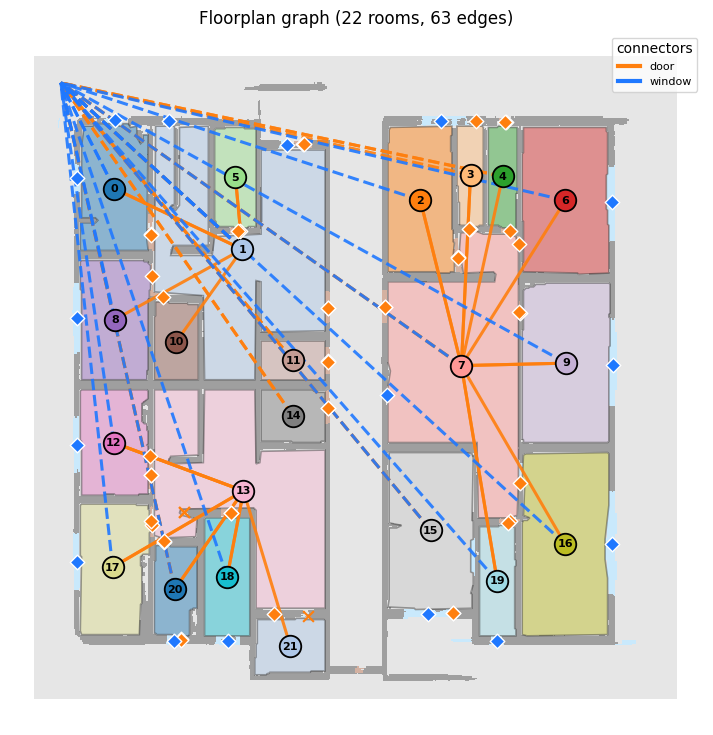

Saved graph JSON: plan_6_mask/plan_6_mask/plan_6_mask_graph.json
Saved cleaned NPY: plan_6_mask/plan_6_mask/plan_6_mask_cleaned.npy
Saved cleaned PNG: plan_6_mask/plan_6_mask/plan_6_mask_cleaned.png
Saved graph PNG: plan_6_mask/plan_6_mask/plan_6_mask_graph.png


In [21]:
# ============================================================
# 18) Save outputs
# ============================================================
graph_json_path = Path(str(OUT_BASE) + "_graph.json")
cleaned_npy_path = Path(str(OUT_BASE) + "_cleaned.npy")
cleaned_png_path = Path(str(OUT_BASE) + "_cleaned.png")
graph_png_path = Path(str(OUT_BASE) + "_graph.png")

with graph_json_path.open("w") as f:
    json.dump(export_data, f, indent=2)
np.save(cleaned_npy_path, cleaned_mask.astype(np.uint8))
Image.fromarray(mask_to_rgb(cleaned_mask)).save(cleaned_png_path)

# Save final plot too
fig = plot_graph(graph, image_size=mask.shape, show_mask=True)
fig.savefig(graph_png_path, dpi=130, bbox_inches="tight")

print(f"Saved graph JSON: {graph_json_path}")
print(f"Saved cleaned NPY: {cleaned_npy_path}")
print(f"Saved cleaned PNG: {cleaned_png_path}")
print(f"Saved graph PNG: {graph_png_path}")
